# Mesh design

In [1]:
import numpy as np
import os
import scipy.sparse as sp
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap, Normalize, SymLogNorm
from matplotlib import cm as colormap
import time
from string import ascii_lowercase
import pickle
from multiprocessing import Pool

from string import ascii_lowercase

# SimPEG, discretize
import discretize
from discretize import utils
from simpeg.electromagnetics import frequency_domain as fdem
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.electromagnetics.utils import line_through_faces
from simpeg import(
    maps, Report, Data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils
)
from simpeg.utils.solver_utils import get_default_solver

from geoana.em.fdem import ElectricDipoleWholeSpace
import utils

In [32]:
from matplotlib import rcParams
rcParams["font.size"] = 12

## Simulation parameters

In [3]:
# # conductivities
sigma_air = 1e-4
sigma_back = np.r_[1e-1]
casing_l = 500
sigma_casing = 5e6
mur_casing = np.r_[1, 2, 10, 25, 50, 100, 150, 200]

# # casing geometry
casing_b = 5e-2  
casing_t = 1e-2 #np.r_[5e-3, 7.5e-3, 10e-3, 12.5e-3, 15e-3, 20e-3]
casing_a = casing_b - casing_t

In [4]:
src_dz = 10
src_z = -casing_l-15 #-515 #np.r_[-100, -250, -400, -495, -500, -550, -600]

In [5]:
# generate a mesh
hx = utils.pad_for_casing_and_data(
   casing_outer_radius = casing_b,
    csx1 = casing_t/4, 
    csx2 = 25, 
    pfx1 = 1.3,
    pfx2 = 1.55, 
    domain_x = 600, 
    npadx = 9
)

pfz = 1.55
npad_z = 22
csz = 0.125 / 2 
n_core_extra = 1
ncore_z = int(np.max(np.r_[np.abs(casing_l), np.abs(src_z)]) / csz) + n_core_extra
hz = discretize.utils.unpack_widths(
    [(csz, npad_z, -pfz), (csz, ncore_z), (csz, npad_z, pfz)]
)

<Axes: xlabel='x', ylabel='z'>

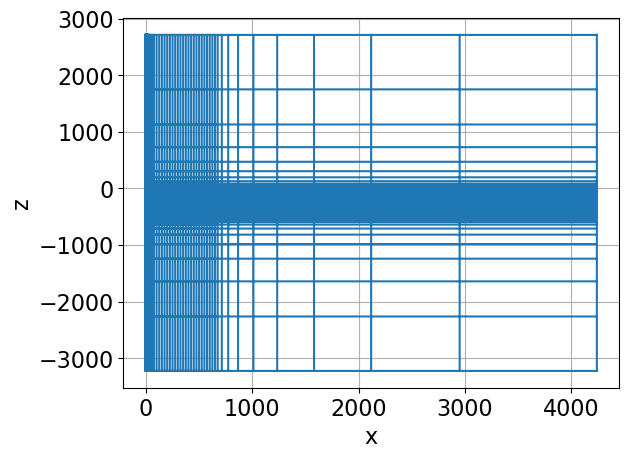

In [6]:
mesh = discretize.CylindricalMesh(
    [hx, np.r_[2*np.pi], hz], origin=np.r_[0, 0, -np.sum(hz[:npad_z + int(ncore_z)])],
)

fig, ax = plt.subplots(1, 1)
mesh.plot_grid(ax=ax)
# ax.set_xlim([0, 5])
# ax.set_ylim(-50, 10)

In [7]:
mesh.n_cells

745650

In [8]:
frequencies = 10**np.linspace(-1, 4, 36)
frequencies

array([1.00000000e-01, 1.38949549e-01, 1.93069773e-01, 2.68269580e-01,
       3.72759372e-01, 5.17947468e-01, 7.19685673e-01, 1.00000000e+00,
       1.38949549e+00, 1.93069773e+00, 2.68269580e+00, 3.72759372e+00,
       5.17947468e+00, 7.19685673e+00, 1.00000000e+01, 1.38949549e+01,
       1.93069773e+01, 2.68269580e+01, 3.72759372e+01, 5.17947468e+01,
       7.19685673e+01, 1.00000000e+02, 1.38949549e+02, 1.93069773e+02,
       2.68269580e+02, 3.72759372e+02, 5.17947468e+02, 7.19685673e+02,
       1.00000000e+03, 1.38949549e+03, 1.93069773e+03, 2.68269580e+03,
       3.72759372e+03, 5.17947468e+03, 7.19685673e+03, 1.00000000e+04])

In [9]:
def skin_depth(sigma, mur, freq):
    return np.sqrt(2/(2*np.pi*freq*sigma*mu_0*mur))

In [10]:
skin_depth(sigma_back, 1, frequencies)

array([5032.92121078, 4269.64296659, 3622.12128874, 3072.80087188,
       2606.78879738, 2211.45076348, 1876.06855001, 1591.54943102,
       1350.17965701, 1145.41532338,  971.70495513,  824.33899787,
        699.32213459,  593.26496647,  503.29212108,  426.96429666,
        362.21212887,  307.28008719,  260.67887974,  221.14507635,
        187.606855  ,  159.1549431 ,  135.0179657 ,  114.54153234,
         97.17049551,   82.43389979,   69.93221346,   59.32649665,
         50.32921211,   42.69642967,   36.22121289,   30.72800872,
         26.06788797,   22.11450763,   18.7606855 ,   15.91549431])

In [11]:
mesh.h[0].min()

np.float64(0.0023114858255602454)

In [12]:
rx_x = np.linspace(25, 500, 20)
rx_z = -np.linspace(0, 600, 25) - csz/2
rx_z

array([-3.1250000e-02, -2.5031250e+01, -5.0031250e+01, -7.5031250e+01,
       -1.0003125e+02, -1.2503125e+02, -1.5003125e+02, -1.7503125e+02,
       -2.0003125e+02, -2.2503125e+02, -2.5003125e+02, -2.7503125e+02,
       -3.0003125e+02, -3.2503125e+02, -3.5003125e+02, -3.7503125e+02,
       -4.0003125e+02, -4.2503125e+02, -4.5003125e+02, -4.7503125e+02,
       -5.0003125e+02, -5.2503125e+02, -5.5003125e+02, -5.7503125e+02,
       -6.0003125e+02])

In [13]:
components = ["x", "z"]
rx_list = utils.create_receivers(rx_x, rx_z, components=components)
src_list = []
src_locations = np.array([
    [0, 0, src_z+src_dz/2.],
    [0, 0, src_z-src_dz/2.]
])
for f in frequencies: 
    src = fdem.sources.LineCurrent(rx_list, location=src_locations, frequency=f)
    src_list.append(src)

wires = maps.Wires(("sigma", mesh.n_cells), ("mur", mesh.n_cells))
permeability_map = maps.MuRelative(mesh)
sigma_map = maps.ExpMap(mesh) 

survey = fdem.Survey(src_list)

sim = fdem.simulation.Simulation3DMagneticField(
    mesh=mesh, sigmaMap=sigma_map * wires.sigma, muMap=permeability_map * wires.mur,
    survey=survey, solver=get_default_solver(), forward_only=True 
)

In [14]:
sigma_wholespace = np.ones(mesh.n_cells) * sigma_back
mur = np.ones(mesh.n_cells)

In [15]:
%%time
fields = sim.fields(np.r_[np.log(sigma_wholespace), mur])

/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)


In [16]:
dpred = sim.make_synthetic_data(np.r_[np.log(sigma_wholespace), mur], f=fields)

In [26]:
e_dipole = ElectricDipoleWholeSpace(
    frequency=frequencies[0], sigma=sigma_back, mu=mu_0, length=src_dz, 
    location=np.r_[0, 0, src_z], orientation="z"
)

In [27]:
j_analytic = {}
e_analytic = {}
h_analytic = {}

e_analytic_data = {}

for f in frequencies: 
    e_dipole.frequency = f
    ex = e_dipole.electric_field(mesh.faces_x)[:, 0]
    ez = e_dipole.electric_field(mesh.faces_z)[:, 2]
    e_analytic[f] = np.r_[ex, ez]

    ex_data = e_dipole.electric_field(discretize.utils.ndgrid(rx_x, np.r_[0], rx_z))[:, 0]
    ez_data = e_dipole.electric_field(discretize.utils.ndgrid(rx_x, np.r_[0], rx_z))[:, 2]
    e_analytic_data[f] = np.r_[ex_data, ez_data]

    jx = e_dipole.current_density(mesh.faces_x)[:, 0]
    jz = e_dipole.current_density(mesh.faces_z)[:, 2]
    j_analytic[f] = np.r_[jx, jz]

    h_analytic[f] = e_dipole.magnetic_field(mesh.edges_y)[:, 1]

In [39]:
len(frequencies)

36

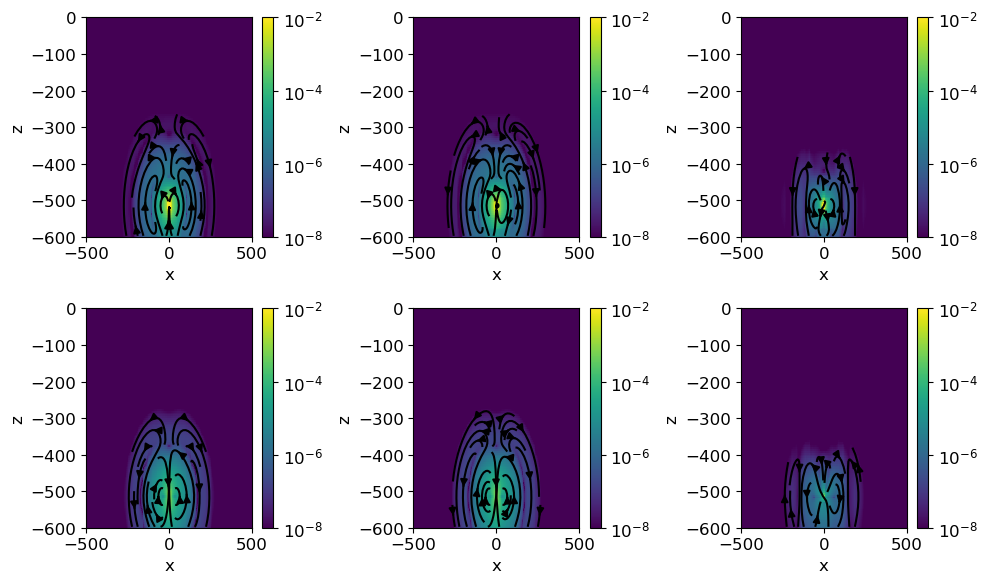

In [40]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))

freq_ind = 30
freq = frequencies[freq_ind]

xlim = np.r_[-1, 1] * 500
ylim = np.r_[-600, 0] 

numeric = np.squeeze(fields[src_list[freq_ind], "e"])
analytic = np.squeeze(e_analytic[freq])
diff = numeric - analytic 

vmin=1e-8
vmax=1e-2

for j, comp in enumerate(["real", "imag"]): 
        
    for i, field in enumerate([numeric, analytic, diff]): 
        plt.colorbar(mesh.plot_image(
            getattr(mesh.average_face_to_cell_vector * field, comp), 
            "CCv",
            view="vec", 
            range_x=xlim, range_y=ylim,
            sample_grid=[5, 5], 
            pcolor_opts = {"norm":LogNorm(vmin=vmin, vmax=vmax)},
            mirror=True,
            stream_threshold=vmin,
            ax=ax[j, i]
        )[0], ax=ax[j, i])
plt.tight_layout()